# ESS optimal feed selection project.



First, let's load the relevant feed data.

In [1]:
!pip install fastparquet
!pip install matplotlib
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

  Using cached fastparquet-2026.3.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.8 MB)
  Using cached cramjam-2.11.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.0 MB)
  Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
  Using cached pillow-12.2.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 

In [2]:
df = pd.read_parquet('ff26_feed.parquet')
df.head()

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925


In [3]:
df.head(1).transpose()

,0
exchange_timestamp,1773008221031041738
message_type,TRADE
symbol,FVP
price,701.67
trade_count,87
volume,275
sequence_number,1
capture_point,handoff_1
capture_ts,1773008221031185558


##### exchange_timestamp
- time in nanos when the exchange broadcast the message
##### message_type
- what information the message contains. For this project it will always be TRADE
##### symbol
- which instrument the message is for. Can think of them as different stocks
##### price
- the price at which the trade occured
##### trade_count
- how many distinct orders participated in the trade. 
##### volume
- how much volume transacted in the trade
##### sequence_number
- a monotonically increasing ID per symbol to allow distinguising between otherwise identical trades and detecting if we have missed a trade (dropped a packet)
##### capture_point
- which distinct path from the exchange we have used to receive this message 
##### capture_ts
- the nanosecond timestamp at which we received this message. Will deterministically be after the exchange_timestamp. Can be NA if this handoff 

Let's dig into one event just to get a sense of the data

Let's choose this first one arbitrarily

In [5]:
one_event = df.loc[(df.symbol=='FVP')&(df.sequence_number==1)]
one_event

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925
5,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_7,1773008221031183037
6,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_8,1773008221031187254
7,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_9,1773008221031183108
8,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_10,1773008221031187444
9,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021


We can see there are multiple capture points "handoffs" that all potentially received a copy of this message.

All fields are the same apart form the capture point and capture timestamp - they all refer to the same trade at the exchange.

In the world of trading, nanoseconds matter! Receiving the same information as fast as possible can make the difference between getting the trade or not.

The System diagram looks something like the following.

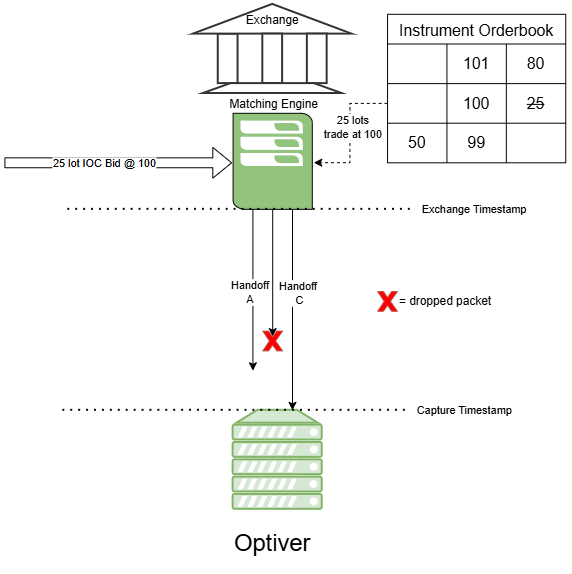

In [6]:
one_event.sort_values('capture_ts')

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
9,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021
5,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_7,1773008221031183037
7,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_9,1773008221031183108
3,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_5,1773008221031185502
1,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_3,1773008221031185506
0,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_1,1773008221031185558
2,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_4,1773008221031185900
4,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_6,1773008221031185925
6,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_8,1773008221031187254
10,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_12,1773008221031187434


Here, sorting by the capture timestamp we can see that handoff_11 received the message first. 

Note we can infer that some handoffs didn't receive this message at all (as there are missing numbers in the list). This can happen if there is some error in the network, and is known as a 'dropped packet'

Let's look into which capture point wins for each event

In [7]:
fastest_indices = df.groupby(['symbol','sequence_number']).capture_ts.idxmin()
fastest_indices

symbol  sequence_number
AEY     1                       75
        2                      298
        3                      530
        4                      758
        5                      981
                            ...   
ZOP     8351               1473638
        8352               1473768
        8353               1473905
        8354               1474042
        8355               1474185
Name: capture_ts, Length: 686832, dtype: int64

In [8]:
winning_points = df.loc[fastest_indices].reset_index(drop=True)
winning_points

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
0,1773008229006019680,TRADE,AEY,713.12,19,492,1,handoff_9,1773008229006087819
1,1773008229034913478,TRADE,AEY,713.12,1,100,2,handoff_7,1773008229034932943
2,1773008229043200423,TRADE,AEY,713.12,1,100,3,handoff_11,1773008229043224459
3,1773008229051587773,TRADE,AEY,713.12,1,100,4,handoff_11,1773008229051616950
4,1773008229058967797,TRADE,AEY,713.12,1,15,5,handoff_7,1773008229058993185
...,...,...,...,...,...,...,...,...,...
686827,1773030597018166609,TRADE,ZOP,715.29,1,1,8351,handoff_12,1773030597018218975
686828,1773030597043717925,TRADE,ZOP,715.29,1,1,8352,handoff_6,1773030597043741951
686829,1773030599018156468,TRADE,ZOP,715.29,1,1,8353,handoff_4,1773030599018181704
686830,1773030600006016828,TRADE,ZOP,715.29,1,1,8354,handoff_3,1773030600006043935


Let's confirm that it correctly determines the winner in our manually verified one!

In [10]:
winning_points.loc[(winning_points.symbol=='FVP')&(winning_points.sequence_number==1)]

,exchange_timestamp,message_type,symbol,price,trade_count,volume,sequence_number,capture_point,capture_ts
28182,1773008221031041738,TRADE,FVP,701.67,87,275,1,handoff_11,1773008221031183021


<Axes: title={'center': 'Handoff win rate'}, xlabel='capture_point'>

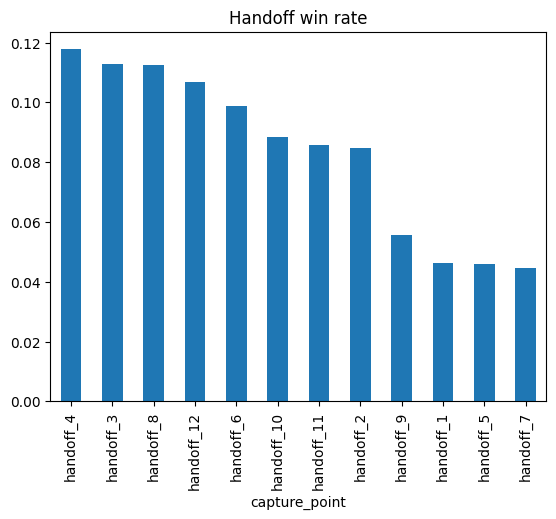

In [11]:
(winning_points.capture_point.value_counts()/winning_points.capture_point.count()).plot(kind='bar',title='Handoff win rate')

So handoff_4 seems to win most often while handoff_7 wins the least.

Let's add a new column called 'latency' to our dataframe that represents the difference between the time the trade occured at the exchange compared to when we received it

In [12]:
df['latency'] = df['capture_ts'] - df['exchange_timestamp']

In [13]:
grouped_latencies = df.groupby('capture_point').latency

In [14]:
grouped_latencies.mean().sort_values()

capture_point
handoff_12    28948.659890
handoff_10    28956.211257
handoff_8     28964.955110
handoff_4     29019.315499
handoff_6     29026.915735
handoff_11    29197.865762
handoff_9     29216.751666
handoff_7     29224.203026
handoff_3     29261.191412
handoff_5     29298.227025
handoff_1     29298.257822
handoff_2     29522.001208
Name: latency, dtype: float64

We can look into some summary statistics for each handoff

In [15]:
grouped_latencies.describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
capture_point,,,,,,,,
handoff_12,670739.0,28948.659890,8687.655320,10555.0,25389.0,27754.0,30381.00,3042618.0
handoff_10,674161.0,28956.211257,8679.492828,10610.0,25398.0,27762.0,30388.00,3042562.0
handoff_8,671371.0,28964.955110,8684.067923,10543.0,25406.0,27772.0,30400.00,3042476.0
handoff_4,672729.0,29019.315499,8728.956626,12375.0,25353.0,27787.0,30529.00,3041529.0
handoff_6,671071.0,29026.915735,8731.981744,12300.0,25362.0,27794.0,30535.00,3041685.0
handoff_11,668565.0,29197.865762,8705.176084,11275.0,25610.0,28003.0,30657.00,3043423.0
handoff_9,668476.0,29216.751666,8706.511466,11222.0,25630.0,28022.0,30674.00,3043438.0
handoff_7,670497.0,29224.203026,8701.849172,11274.0,25638.0,28031.0,30682.00,3043430.0
handoff_3,670131.0,29261.191412,8748.767779,11545.0,25574.0,28036.0,30803.00,3043307.0


Which of these do you think would be most interesting? What are some interesting observations we can make from this table?

### Question 1:
### If you had to select 2 handoffs for feed to connect to your autotrader which 2 would would pick and why?

In [33]:
# You should have sufficient confidence to pick 2 handoffs after 10 minutes on this question, looking at the latency of the different handoffs.

### Question 2:
### Currently your autotrader only supports 2 handoffs, but what gain would we get from adding additional handoffs? What would be an optimal number?

In [34]:
# Spend 20 minutes on this question.

### Question 3
### Is there anything else interesting you found in the data?

In [35]:
# There are 10 interesting features that you can find. Spend the remaining time on this question

### Some ideas to get you started:
##### Latency
##### Dropped packets
##### Time of day
##### Network traffic